# Galaxy System

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# astropy
from astropy.io import fits
from astropy.wcs import WCS


In [2]:
#directory of the fits file 
directory = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848/"
# data cubes and mask 
data_cube = fits.getdata(directory + "S0116+4114_HIcube2_clean_image_4_cube.fits")
mask_cube = fits.getdata(directory + "S0116+4114_HIcube2_clean_image_4_mask.fits"
"")
# smooth data 
data_cube_smooth = fits.getdata(directory + "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits")
mask_cube_smooth = fits.getdata(directory + "S0116+4114_HIcube2_clean_smooth_image_4_mask.fits")

In [3]:
# inspect the header 
header = fits.getheader(directory + "S0116+4114_HIcube2_clean_image_4_cube.fits")


In [4]:
header

SIMPLE  =                    T                                                  
BITPIX  =                  -32                                                  
NAXIS   =                    3                                                  
NAXIS1  =                   70                                                  
NAXIS2  =                   61                                                  
NAXIS3  =                   71                                                  
CTYPE1  = 'RA---TAN'                                                            
CRPIX1  =    6.24500000000E+02                                                  
CDELT1  =   -1.66666700000E-03                                                  
CRVAL1  =    1.90320943370E+01                                                  
CTYPE2  = 'DEC--TAN'                                                            
CRPIX2  =    4.77500000000E+02                                                  
CDELT2  =    1.66666700000E-

In [5]:
# inspect data dimension
print("Data cube shape:", data_cube.shape)
# the first axis is the velocity axis, the second and third axes are the spatial axes (RA and Dec)
print("Mask cube shape:", mask_cube.shape)
print("Smooth data cube shape:", data_cube_smooth.shape)
print("Smooth mask cube shape:", mask_cube_smooth.shape)

Data cube shape: (71, 61, 70)
Mask cube shape: (71, 61, 70)
Smooth data cube shape: (71, 63, 75)
Smooth mask cube shape: (71, 63, 75)


In [6]:
# ctype 3 is in frequency, we need to convert it to velocity
# we can use the formula: v = c * (f - f0) / f0
# where c is the speed of light, f is the frequency, and f0 is the rest frequency of the HI line (1420.40575 MHz)
c = 299792.458 # speed of light in km/s
f0 = 1420.40575 # rest frequency of the HI line in MHz
f = header['CRVAL3'] + np.arange(header['NAXIS3']) * header['CDELT3'] # frequency array in HZ
f =f / 1e6 # convert frequency to MHz
v = c * (f - f0) / f0 # velocity array in km/s

In [7]:
v.shape

(71,)

In [8]:
# apply mask to the data cube
masked_data=np.where(mask_cube,data_cube,0) 
masked_data_smooth=np.where(mask_cube_smooth,data_cube_smooth,0)

In [9]:
print(v[1]-v[-0])
print(header['CDELT3'])

7.729289824377702
36621.09375


In [12]:
mom0_dat = np.nansum(masked_data,axis=0) * (v[1] - v[0]) # km/s
mom0_dat_smooth = np.nansum(masked_data_smooth,axis=0) * (v[1] - v[0]) # km/s


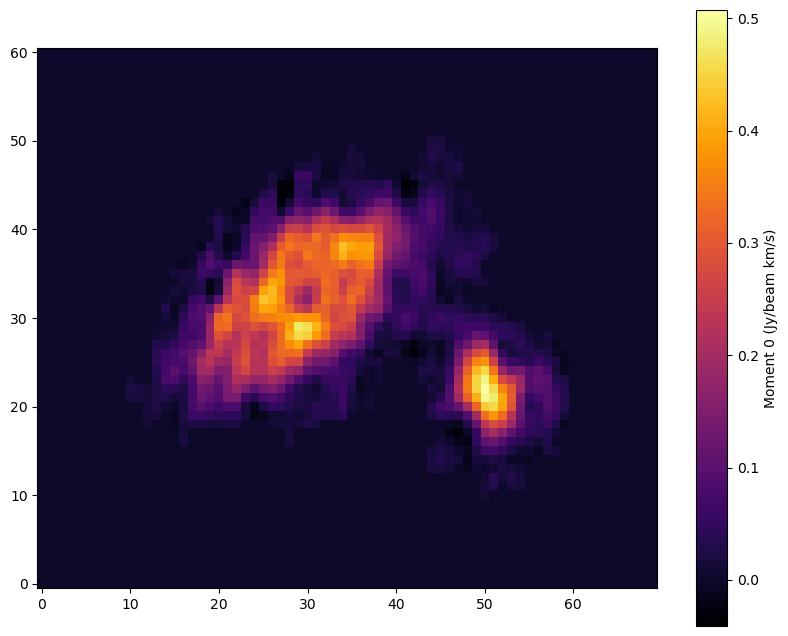

In [11]:
plt.figure(figsize=(10, 8))
plt.imshow(mom0_dat, origin='lower', cmap='inferno')
plt.colorbar(label='Moment 0 (Jy/beam km/s)')
plt.show()

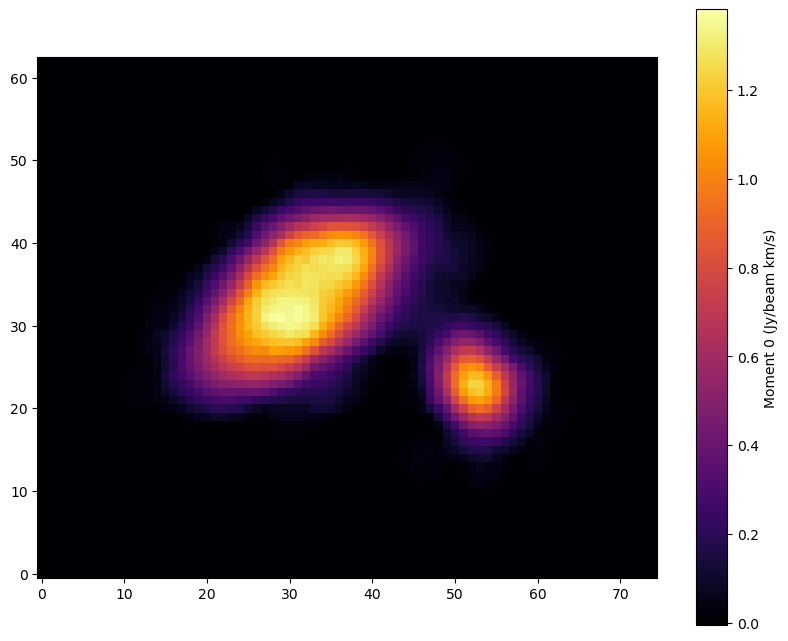

In [13]:
plt.figure(figsize=(10, 8))
plt.imshow(mom0_dat_smooth, origin='lower', cmap='inferno')
plt.colorbar(label='Moment 0 (Jy/beam km/s)')
plt.show()